# Explore features — dfi-quant

Toutes les features sont construites **en espace rendements** à partir des prix OHLCV journaliers.

| Feature | Description | Source |
|---|---|---|
| `ret_1d` | Log-rendement journalier `log(close_t / close_{t-1})` | ohlcv_1d |
| `mom_20d` | Rendement cumulé 20j = `log(close_t / close_{t-20})` | ohlcv_1d |
| `rv_30d` | Volatilité réalisée 30j annualisée = `std(ret_1d, 30) × √365` | ohlcv_1d |
| `cvd_20d` | Pression nette acheteuse 20j, normalisée par le volume | ohlcv_1d |

In [1]:
import pathlib, sys
ROOT = pathlib.Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from dfi_features.ret_1d  import compute as ret_compute
from dfi_features.mom_20d import compute as mom_compute
from dfi_features.rv_30d  import compute as rv_compute
from dfi_features.cvd_20d import compute as cvd_compute

RAW      = ROOT / 'data' / 'raw'
EXCHANGE = 'binance-futures'
SYMBOLS  = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']
COLORS   = {'BTCUSDT': 'tab:orange', 'ETHUSDT': 'tab:blue', 'SOLUSDT': 'tab:purple'}

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('ROOT:', ROOT)

ROOT: /Users/ayman/Downloads/dfi-quant


In [2]:
def load_ohlcv(symbol: str) -> pd.DataFrame:
    base = RAW / f'exchange={EXCHANGE}' / 'data_type=ohlcv_1d' / f'symbol={symbol}'
    frames = [pd.read_parquet(f) for f in sorted(base.rglob('part-*.parquet'))]
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df['date'] = pd.to_datetime(df['ts_open'], unit='us', utc=True).dt.normalize()
    return df.sort_values('date').set_index('date')


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    ret  = ret_compute(df,  {})
    mom  = mom_compute(df,  {'window_d': 20})
    rv   = rv_compute(df,   {'window_d': 30})
    cvd  = cvd_compute(df,  {'window_d': 20})
    fwd  = ret.shift(-1).rename('fwd_ret_1d')   # rendement du lendemain (cible)
    return pd.DataFrame({
        'close': df['close'],
        'ret_1d': ret, 'mom_20d': mom,
        'rv_30d': rv,  'cvd_20d': cvd,
        'fwd_ret_1d': fwd,
    })


data = {sym: build_features(load_ohlcv(sym)) for sym in SYMBOLS}
for sym, df in data.items():
    n_ret = df['ret_1d'].notna().sum()
    print(f'{sym}: {len(df)} jours  |  ret_1d={n_ret}  mom_20d={df["mom_20d"].notna().sum()}  rv_30d={df["rv_30d"].notna().sum()}')

BTCUSDT: 2322 jours  |  ret_1d=2321  mom_20d=2302  rv_30d=2292
ETHUSDT: 2322 jours  |  ret_1d=2321  mom_20d=2302  rv_30d=2292
SOLUSDT: 2065 jours  |  ret_1d=2064  mom_20d=2045  rv_30d=2035


## 1. Rendements journaliers — BTCUSDT

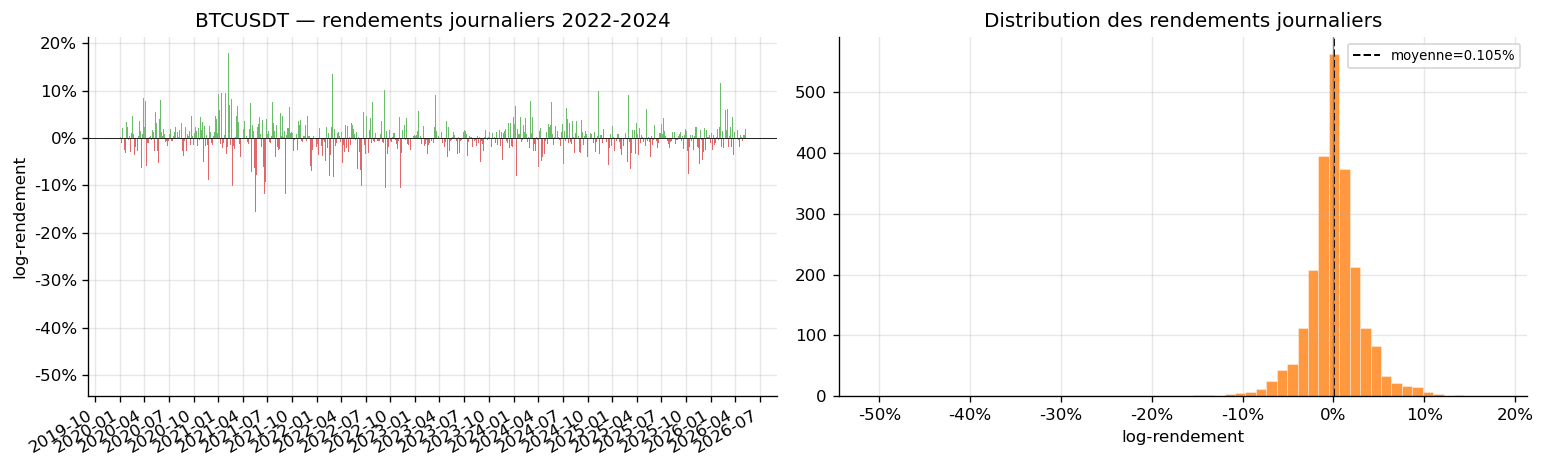

Annualisé  | Rendement moyen : 38.3%  |  Volatilité : 62.6%
Journalier | Skewness : -1.62  |  Kurtosis : 28.12


In [3]:
btc = data['BTCUSDT']
ret = btc['ret_1d'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Série temporelle
ax = axes[0]
colors_bar = ['tab:green' if r >= 0 else 'tab:red' for r in ret]
ax.bar(ret.index, ret.values, color=colors_bar, alpha=0.7, width=1)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('BTCUSDT — rendements journaliers 2022-2024')
ax.set_ylabel('log-rendement')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Distribution
ax = axes[1]
ax.hist(ret.values, bins=60, color='tab:orange', alpha=0.8, edgecolor='white', lw=0.3)
ax.axvline(ret.mean(), color='k', lw=1.2, linestyle='--', label=f'moyenne={ret.mean():.3%}')
ax.axvline(0, color='gray', lw=0.8)
ax.set_title('Distribution des rendements journaliers')
ax.set_xlabel('log-rendement')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Annualisé  | Rendement moyen : {ret.mean()*365:.1%}  |  Volatilité : {ret.std()*np.sqrt(365):.1%}')
print(f'Journalier | Skewness : {ret.skew():.2f}  |  Kurtosis : {ret.kurtosis():.2f}')

## 2. Comparaison des rendements — 3 actifs

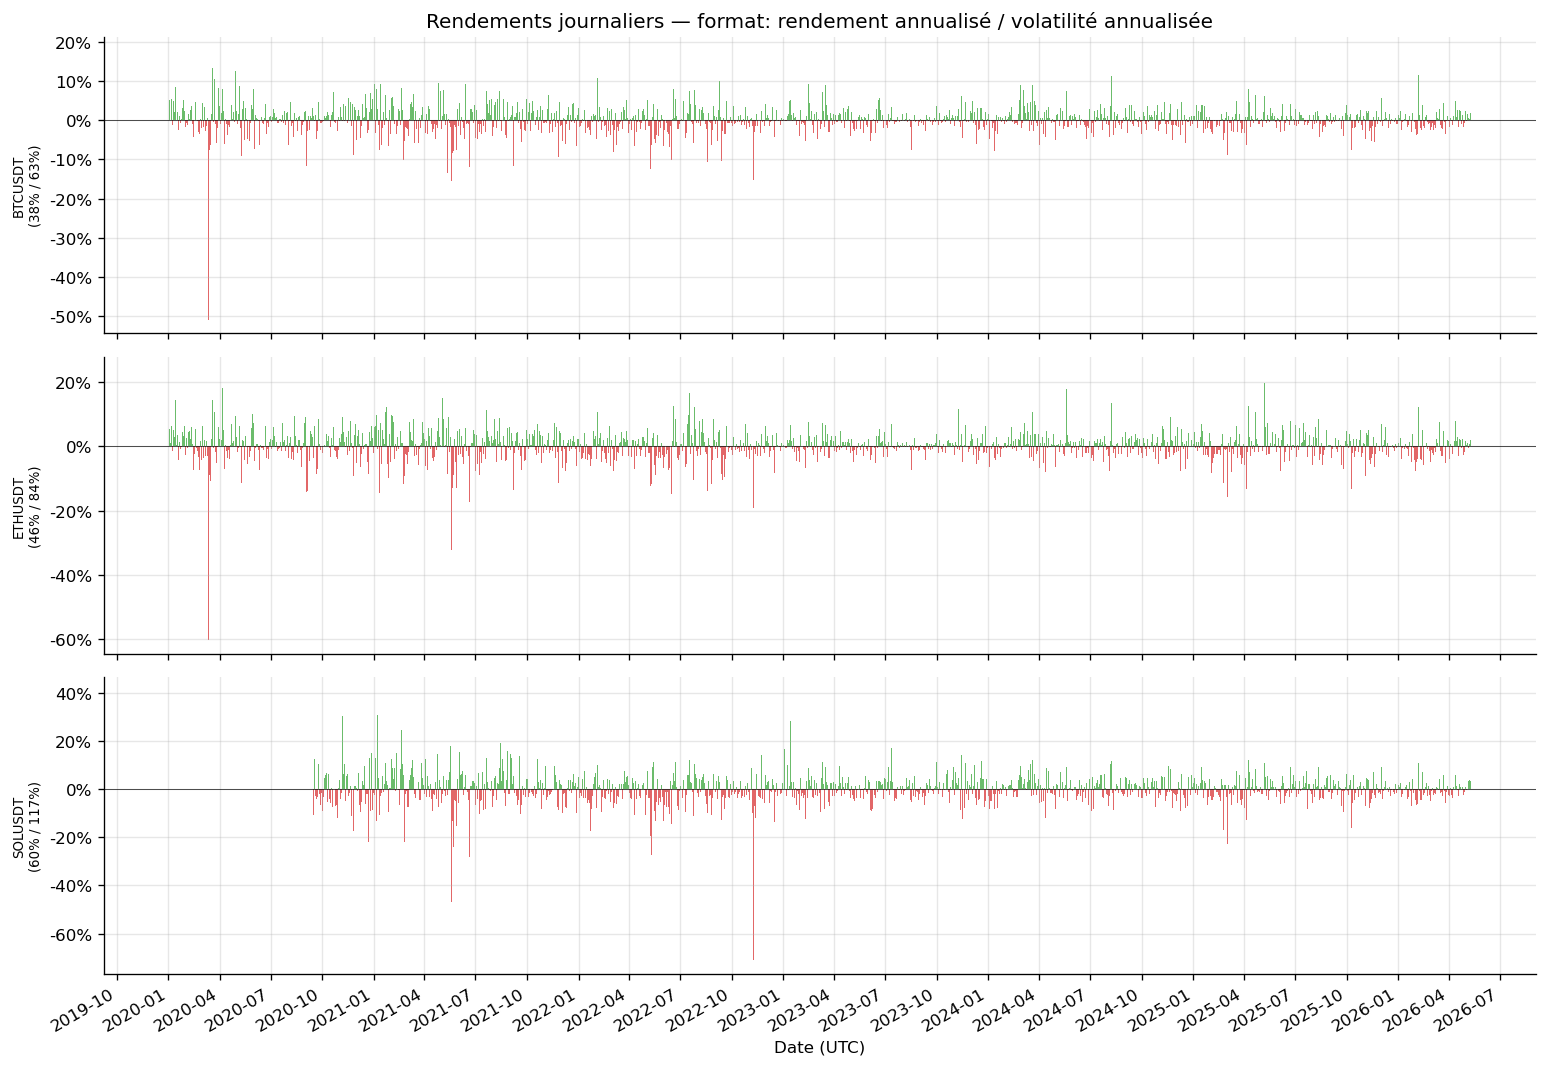

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, sym in zip(axes, SYMBOLS):
    ret = data[sym]['ret_1d'].dropna()
    col = ['tab:green' if r >= 0 else 'tab:red' for r in ret]
    ax.bar(ret.index, ret.values, color=col, alpha=0.7, width=1)
    ax.axhline(0, color='k', lw=0.4)
    ann_ret = ret.mean() * 365
    ann_vol = ret.std() * np.sqrt(365)
    ax.set_ylabel(f'{sym}\n({ann_ret:.0%} / {ann_vol:.0%})', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

axes[0].set_title('Rendements journaliers — format: rendement annualisé / volatilité annualisée')
axes[-1].set_xlabel('Date (UTC)')
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.gcf().autofmt_xdate(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Features en espace rendements — BTCUSDT

- `mom_20d` : direction du marché sur 20j (momentum)
- `rv_30d` : amplitude des mouvements sur 30j (risque)
- `cvd_20d` : pression acheteuse/vendeuse sur 20j (flow)

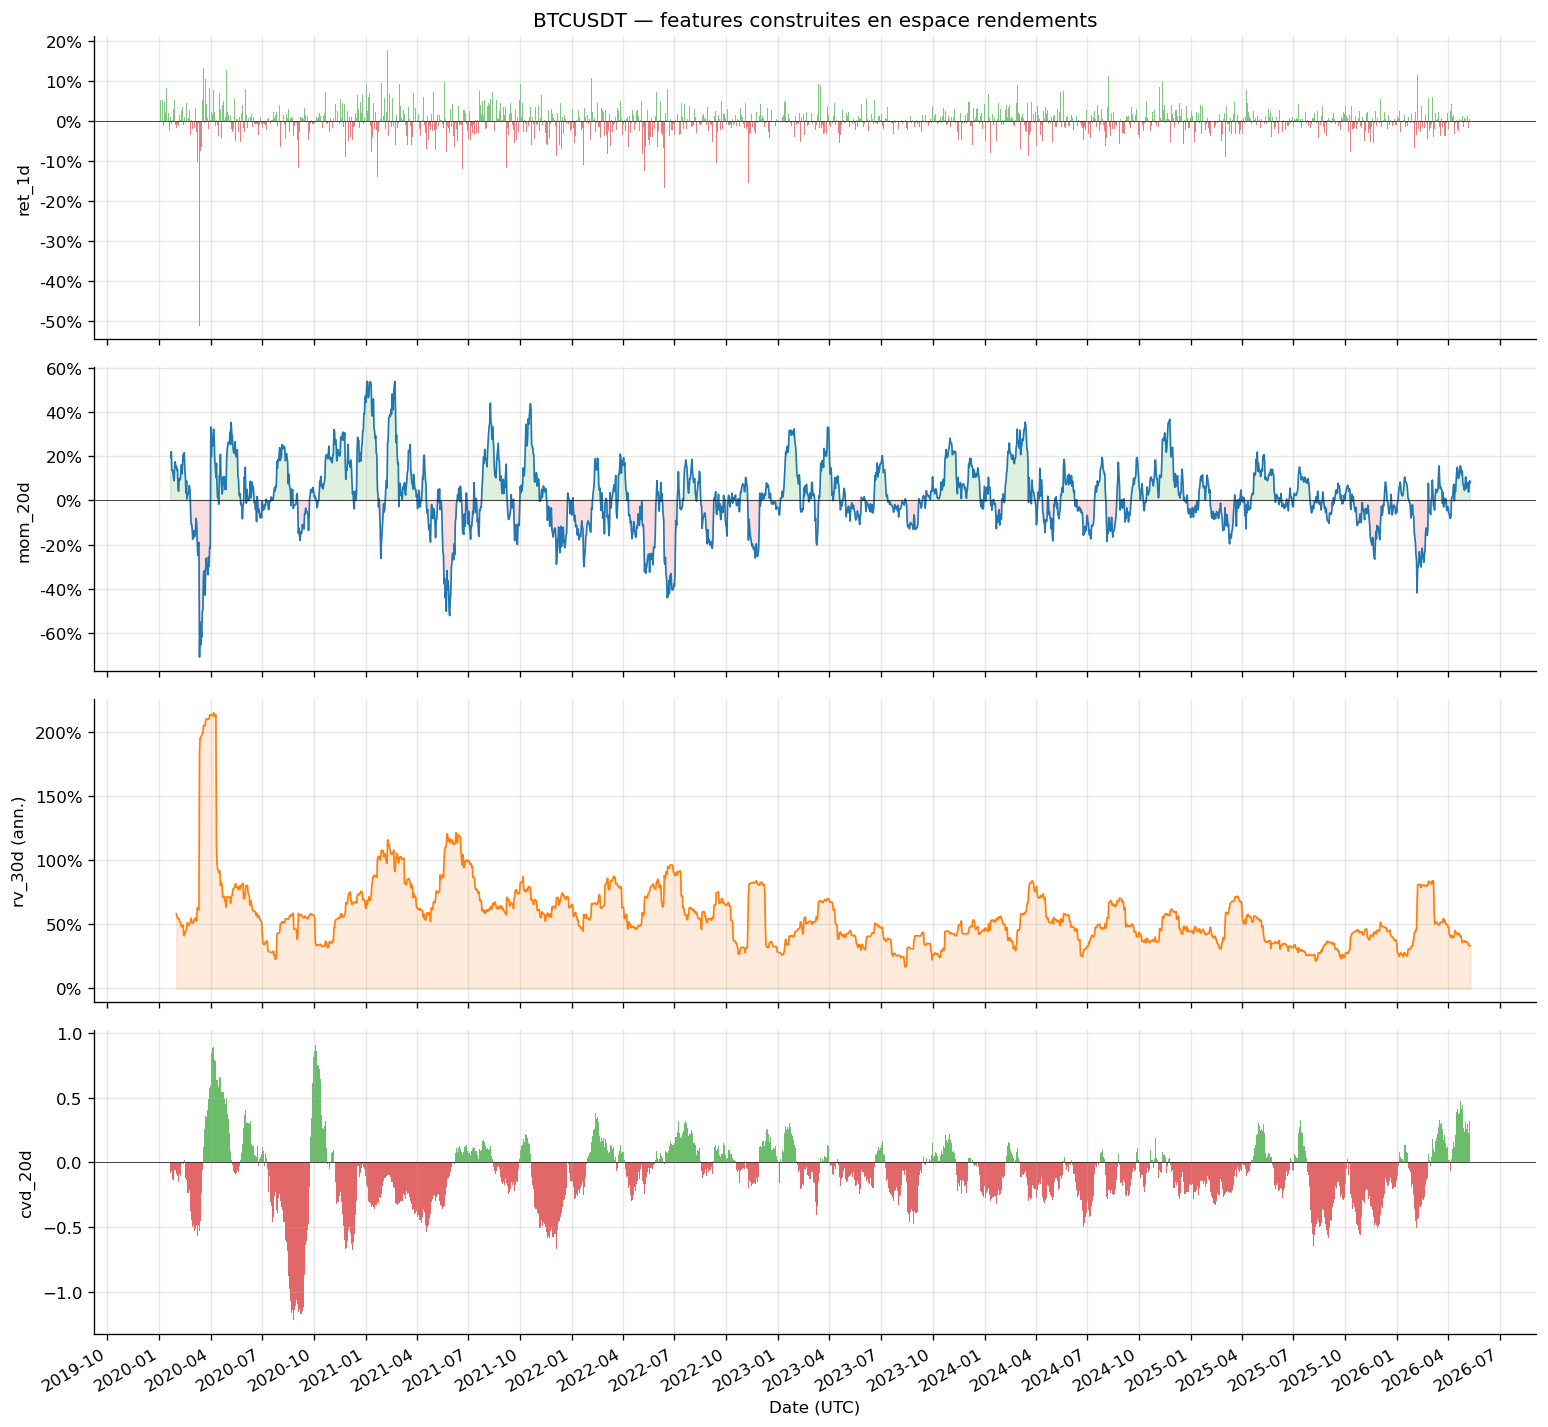

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# ret_1d
ret = btc['ret_1d'].dropna()
ax = axes[0]
col = ['tab:green' if r >= 0 else 'tab:red' for r in ret]
ax.bar(ret.index, ret.values, color=col, alpha=0.6, width=1)
ax.axhline(0, color='k', lw=0.4)
ax.set_ylabel('ret_1d')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_title('BTCUSDT — features construites en espace rendements')

# mom_20d
ax = axes[1]
mom = btc['mom_20d'].dropna()
ax.plot(mom.index, mom.values, color='tab:blue', lw=1.0)
ax.fill_between(mom.index, 0, mom.values,
                where=mom.values >= 0, color='tab:green', alpha=0.15)
ax.fill_between(mom.index, 0, mom.values,
                where=mom.values < 0,  color='tab:red',   alpha=0.15)
ax.axhline(0, color='k', lw=0.4)
ax.set_ylabel('mom_20d')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# rv_30d
ax = axes[2]
rv = btc['rv_30d'].dropna()
ax.plot(rv.index, rv.values, color='tab:orange', lw=1.0)
ax.fill_between(rv.index, 0, rv.values, color='tab:orange', alpha=0.15)
ax.set_ylabel('rv_30d (ann.)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# cvd_20d
ax = axes[3]
cvd = btc['cvd_20d'].dropna()
col = ['tab:green' if v >= 0 else 'tab:red' for v in cvd]
ax.bar(cvd.index, cvd.values, color=col, alpha=0.7, width=1)
ax.axhline(0, color='k', lw=0.4)
ax.set_ylabel('cvd_20d')
ax.set_xlabel('Date (UTC)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
plt.gcf().autofmt_xdate(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. IC proxy — feature_t prédit-il fwd_ret_1d ?

IC = corrélation de rang (Spearman) entre la feature au jour t et le rendement au jour t+1.  
|IC| > 0.05 est généralement considéré comme significatif.

In [6]:
FEATURES = ['ret_1d', 'mom_20d', 'rv_30d', 'cvd_20d']

rows = []
for sym in SYMBOLS:
    df = data[sym].dropna(subset=['fwd_ret_1d'])
    for feat in FEATURES:
        sub = df[[feat, 'fwd_ret_1d']].dropna()
        if len(sub) < 30:
            continue
        ic = sub.corr(method='spearman').iloc[0, 1]
        rows.append({'symbol': sym, 'feature': feat, 'IC': round(ic, 4), 'n': len(sub)})

ic_df = pd.DataFrame(rows).pivot(index='feature', columns='symbol', values='IC')
ic_df = ic_df.loc[FEATURES]  # conserver l'ordre
print(ic_df.to_string())
print('\nNote: ret_1d IC mesure l\'autocorrélation des rendements (tendance vs mean-reversion)')

symbol   BTCUSDT  ETHUSDT  SOLUSDT
feature                           
ret_1d   -0.0625  -0.0599  -0.0158
mom_20d  -0.0010   0.0024   0.0258
rv_30d   -0.0017   0.0013   0.0093
cvd_20d   0.0260  -0.0279  -0.0019

Note: ret_1d IC mesure l'autocorrélation des rendements (tendance vs mean-reversion)


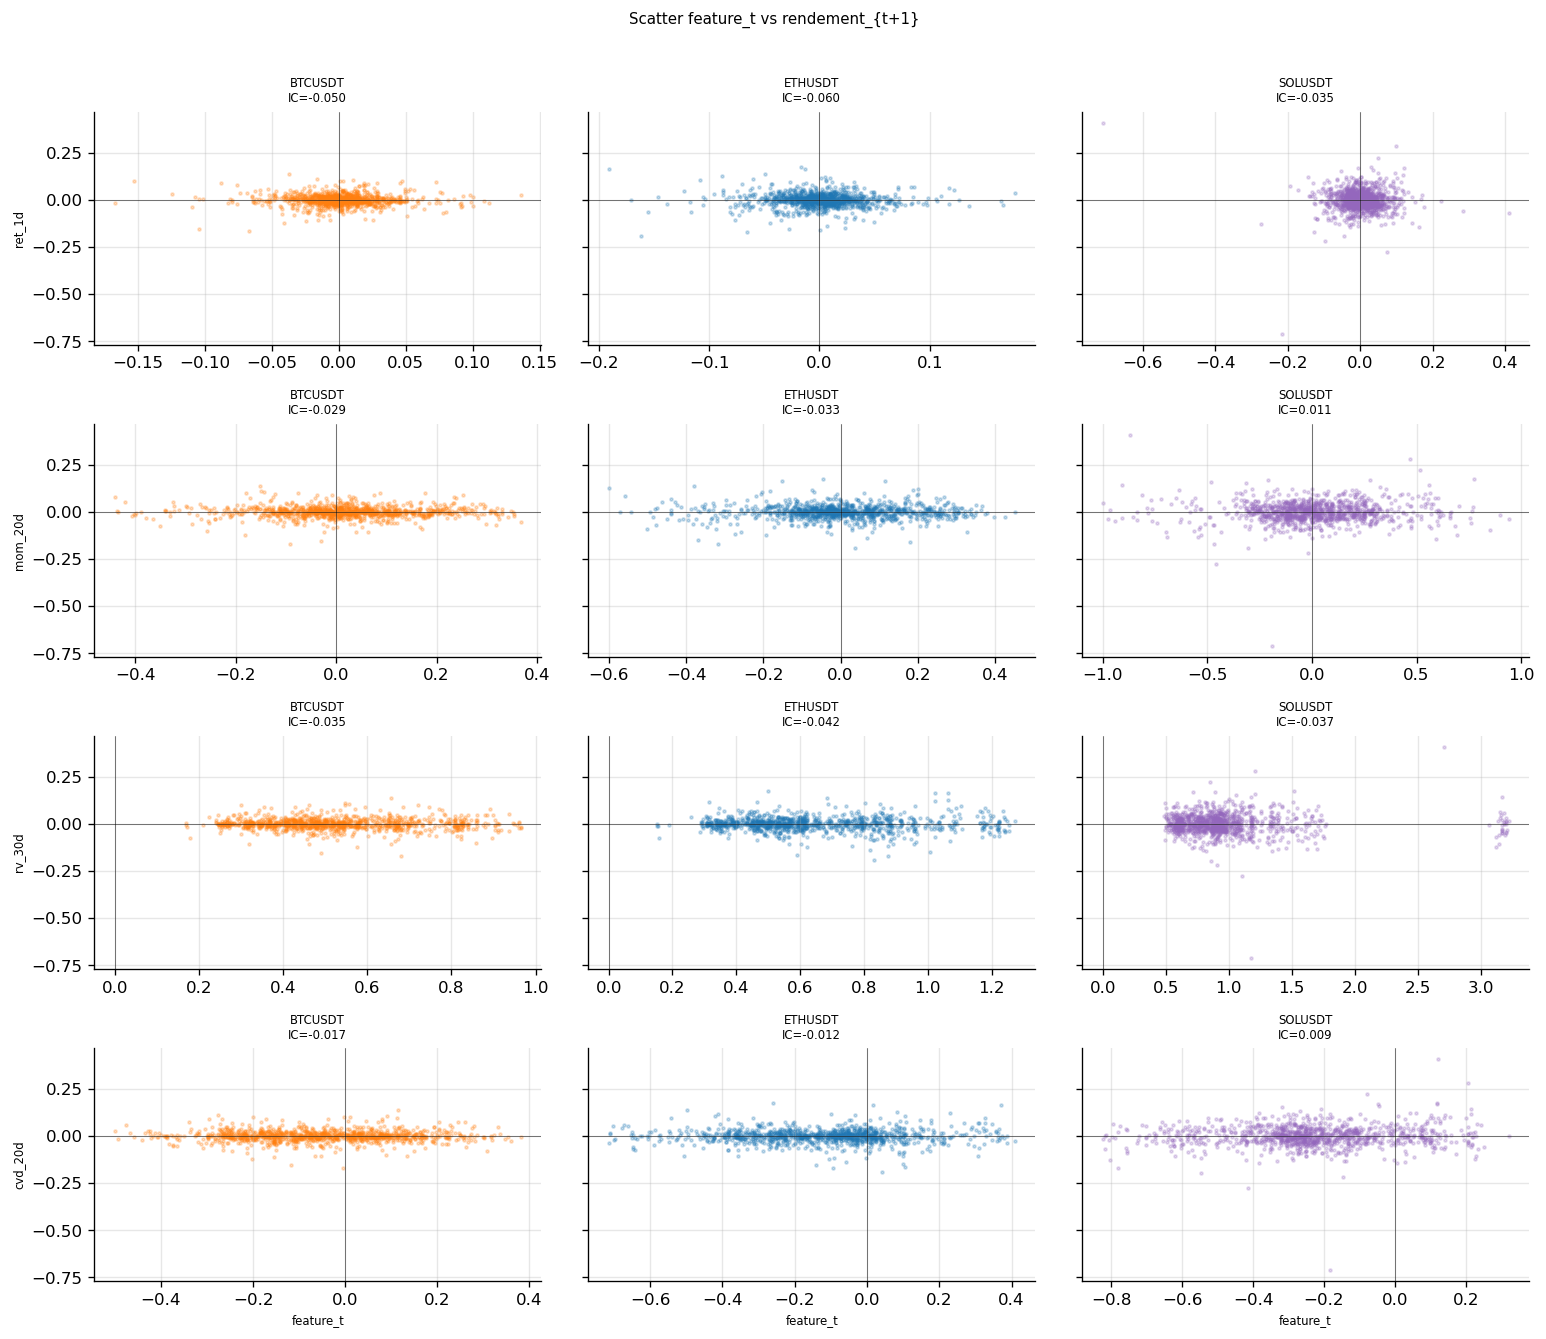

In [7]:
fig, axes = plt.subplots(len(FEATURES), 3, figsize=(13, 11), sharey='row')

for row_i, feat in enumerate(FEATURES):
    for col_i, sym in enumerate(SYMBOLS):
        ax = axes[row_i][col_i]
        df = data[sym][[feat, 'fwd_ret_1d']].dropna()
        ax.scatter(df[feat], df['fwd_ret_1d'], s=3, alpha=0.25, color=COLORS[sym])
        ic = df.corr(method='spearman').iloc[0, 1]
        ax.set_title(f'{sym}\nIC={ic:.3f}', fontsize=7)
        ax.axhline(0, color='k', lw=0.3)
        ax.axvline(0, color='k', lw=0.3)
        if col_i == 0:
            ax.set_ylabel(feat, fontsize=7)
        if row_i == len(FEATURES) - 1:
            ax.set_xlabel('feature_t', fontsize=7)

plt.suptitle('Scatter feature_t vs rendement_{t+1}', fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

## 5. Statistiques des rendements — 3 actifs

In [8]:
rows = []
for sym in SYMBOLS:
    ret = data[sym]['ret_1d'].dropna()
    rows.append({
        'symbol':          sym,
        'rend. annualisé': f'{ret.mean()*365:.1%}',
        'vol. annualisée': f'{ret.std()*np.sqrt(365):.1%}',
        'sharpe (brut)':   f'{ret.mean()/ret.std()*np.sqrt(365):.2f}',
        'skewness':        f'{ret.skew():.2f}',
        'kurtosis':        f'{ret.kurtosis():.2f}',
        'max drawdown':    f'{(ret.cumsum() - ret.cumsum().cummax()).min():.1%}',
    })

stats = pd.DataFrame(rows).set_index('symbol')
print(stats.to_string())

        rend. annualisé vol. annualisée sharpe (brut) skewness kurtosis max drawdown
symbol                                                                              
BTCUSDT           22.4%           54.5%          0.41    -0.18     4.30      -110.1%
ETHUSDT           -4.0%           68.3%         -0.06    -0.15     4.15      -134.8%
SOLUSDT            1.8%          107.7%          0.02    -1.43    26.46      -290.9%
